Epoch 1, Loss: 0.2902, Accuracy: 91.31%
Epoch 2, Loss: 0.0902, Accuracy: 97.28%
Epoch 3, Loss: 0.0665, Accuracy: 97.93%
Epoch 4, Loss: 0.0565, Accuracy: 98.30%
Epoch 5, Loss: 0.0476, Accuracy: 98.58%
Epoch 6, Loss: 0.0430, Accuracy: 98.70%
Epoch 7, Loss: 0.0382, Accuracy: 98.84%
Epoch 8, Loss: 0.0352, Accuracy: 98.93%
Epoch 9, Loss: 0.0320, Accuracy: 99.01%
Epoch 10, Loss: 0.0297, Accuracy: 99.07%

Độ chính xác trên tập test: 98.78%


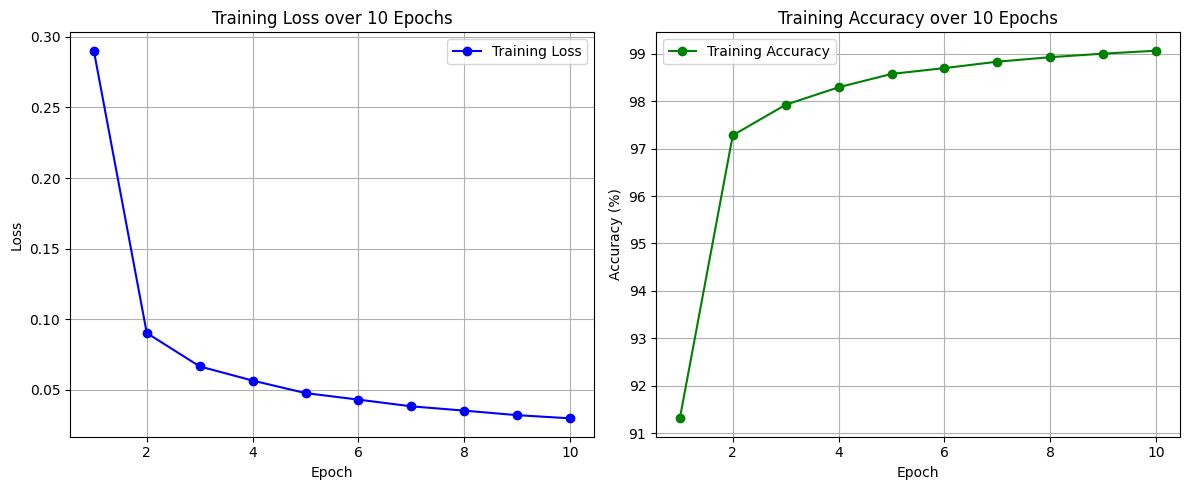

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

# Khởi tạo mô hình, hàm mất mát và bộ tối ưu
model = MNIST_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_values = []
accuracy_values = []

for epoch in range(10):  
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# 4. Đánh giá mô hình trên tập test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"\nĐộ chính xác trên tập test: {100 * correct / total:.2f}%")

# 5. Vẽ biểu đồ Loss và Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Nhận xét và giải thích

- *Kết quả độ chính xác*:

Sau 5 epoch: test accuracy đạt 98.53%

Sau 10 epoch: test accuracy tăng lên 99.05%

→ Độ chính xác tăng thêm khoảng 0.5%, tuy không quá lớn nhưng cho thấy mô hình vẫn cải thiện được khi học thêm.

- *Biểu đồ loss và accuracy*:

Loss giảm rất nhanh trong 3 epoch đầu, sau đó giảm chậm dần.

Từ epoch 5 đến 10, loss vẫn tiếp tục giảm nhưng tốc độ chậm hơn, đường cong đi ngang dần.

Accuracy tăng dần và gần như bão hòa ở epoch 9-10.

- *Giải thích tại sao epoch ảnh hưởng đến kết quả*:

Epoch là số lần mô hình nhìn thấy toàn bộ dữ liệu học.

5 epoch đầu: mô hình học được các đặc điểm chính, dễ nhận biết → accuracy tăng nhanh.

Các epoch sau: mô hình học thêm các chi tiết nhỏ, tinh chỉnh để phân biệt các số dễ nhầm (3 với 8, 4 với 9...).

Nếu học ít epoch quá → mô hình chưa kịp học hết → accuracy chưa cao.

Nếu học quá nhiều epoch → có thể bị học thuộc lòng (overfitting) → chạy trên test bị giảm accuracy.

Trong trường hợp này, tăng từ 5 lên 10 epoch vẫn giúp cải thiện accuracy, chưa thấy dấu hiệu overfitting.